# 프로젝트 진행 일지: SmartPitch MDP 전이확률 모델 비교

**기간**: 2026-05-06 ~ 2026-05-27 (Phase 10 완료)
**목적**: SmartPitch MDP의 전이확률 추정 모델을 동일 데이터로 비교하고 MDP 호환 10-class 모델 개발

## 비교 모델 (Phase 10 완료 기준)

| | Model A | Model B | Model C | TransitionModelMLP10 |
|---|---|---|---|---|
| 이름 | Baseline | Otremba 2022 MLP | MIT Sloan 2025 Transformer | Arsenal Context MLP |
| 입력 | 경험적 lookup | 77d 단일 벡터 | 87d × 400 시퀀스 | 135d (77d + arsenal 58d) |
| 출력 | 4-class | 4-class | 10-class + HL + cont | 10-class |
| Top-1 | 35.6% | 60.9% | 67.2% | **67.6%** |
| MDP 호환 | ✅ | ✅ | ❌ | **✅ ⭐** |

## 이 노트북의 역할

- 프로젝트 전 과정의 결정, 이슈, 해결 기록 (Phase 1~10)
- 발표 자료 / 팀 onboarding / 개인 회고

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('환경 설정 완료')

환경 설정 완료


---
# Day 1: 2026-05-06 (Mac M-series)

## Phase 1–2: 환경 셋업 + 데이터 수집

### 환경

- **플랫폼**: Mac M-series (Apple Silicon, MPS)
- **Python**: 3.12, **패키지 관리**: uv
- **딥러닝**: PyTorch (MPS 백엔드)
- **실험 추적**: W&B, **설정**: OmegaConf + YAML

```
uv init transition-models
uv add torch torchvision wandb pybaseball pandas numpy ...
```

### 데이터 수집 (Phase 2)

```python
from pybaseball import statcast
df_2023 = statcast('2023-03-30', '2023-11-01')
df_2024 = statcast('2024-03-28', '2024-10-01')
```

| 항목 | 값 |
|------|---|
| 2023 시즌 | 774,038 투구 |
| 2024 시즌 | 760,248 투구 |
| 합계 | **1,534,286 투구**, 118 컬럼 |
| 형식 | Parquet (빠른 로드, 타입 보존) |

## Phase 3: 전처리 + 핵심 설계 결정 (Lazy Loading) ⭐

### 3.1 데이터 정제

| 단계 | 제거 대상 | 결과 |
|------|-----------|------|
| deprecated 컬럼 | 8개 (100% null) | 컬럼 제거 |
| truncated_pa | 660건 (10-class 매핑 불가) | row 제거 |
| null pitch_type | ~36,000건 | row 제거 |
| **정제 후** | | **1,488,976 rows (-3.0%)** |

### 3.2 Feature 설계

- **Model B (77-dim)**: 연속(15) + one-hot 그룹들(62)
- **Model C (87-dim)**: 위에 result(10) + hit_location(9) 추가, inning(9) 제거
- **4-class**: Ball / Strike / Foul / InPlay
- **10-class**: Ball / Strike / Single / Double / Triple / HR / FieldOut / Strikeout / Walk / HBP

### 3.3 메모리 위기와 Lazy Loading 해결 ⭐

Model C는 한 타자의 400 pitch 시퀀스를 입력으로 사용한다.
처음에는 모든 시퀀스를 메모리에 올리는 **Eager Loading**을 고려했다.

**문제 발견:**
```
521,680 sequences × 400 pitches × 87 features × 4 bytes (float32)
= 72.6 GB  ← Mac 메모리 한계 초과!
```

**해결: Lazy Loading 패턴 설계**
- 전처리: 전체 vectors를 `(N, 87)` numpy 배열로 저장 (`vectors_c_*.npy`)
- 인덱스: 각 시퀀스의 시작점만 저장 (`indices_*.pkl`)
- `__getitem__`: O(1) numpy 슬라이싱으로 배치 생성 (메모리에 시퀀스 없음)

```python
def __getitem__(self, idx):
    _, global_start = self.valid_indices[idx]
    seq = self.vectors[global_start:global_start + 400].copy()  # O(1)
    seq[-1, 68:87] = 0.0  # Sub-token mask
    return {"sequence": torch.from_numpy(seq).float(), ...}
```

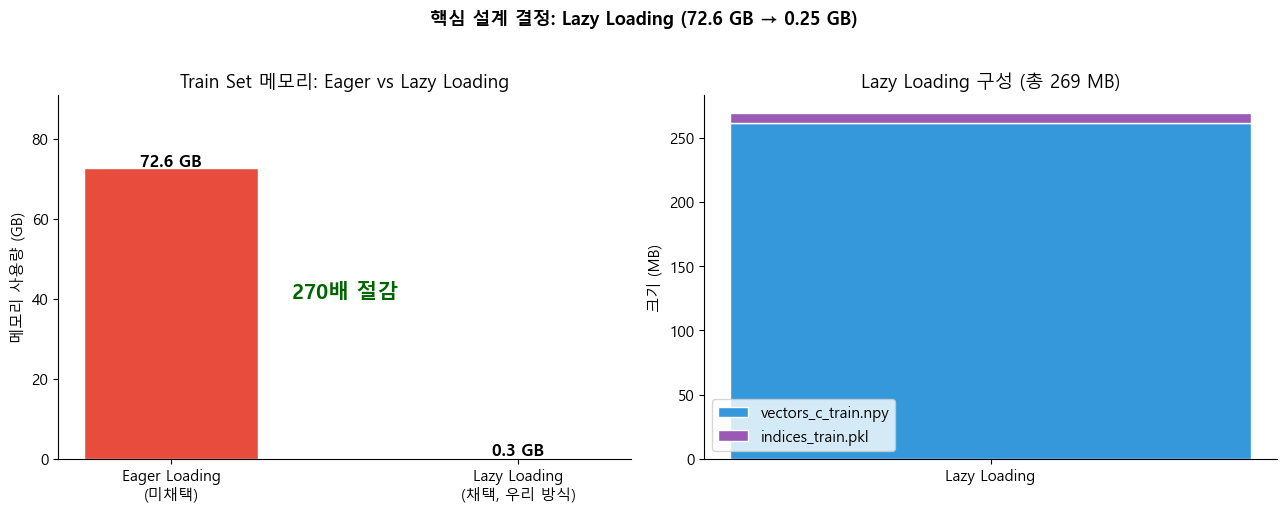

절감: 72.6 GB → 0.27 GB (270배 ↓)


In [2]:
# Lazy Loading 메모리 비교 시각화
n_seqs = 521_680
seq_len = 400
n_feat = 87
f32 = 4  # bytes

eager_gb = n_seqs * seq_len * n_feat * f32 / 1e9
n_rows = 749_880
lazy_vecs_gb = n_rows * n_feat * f32 / 1e9
lazy_idx_mb = n_seqs * 2 * 8 / 1e6  # (batter_id, start) × int64
lazy_total_gb = lazy_vecs_gb + lazy_idx_mb / 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 비교 막대 그래프
labels = ['Eager Loading\n(미채택)', 'Lazy Loading\n(채택, 우리 방식)']
values = [eager_gb, lazy_total_gb]
colors = ['#E74C3C', '#2ECC71']

bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f} GB', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('메모리 사용량 (GB)')
axes[0].set_title('Train Set 메모리: Eager vs Lazy Loading')
axes[0].set_ylim(0, eager_gb * 1.25)
axes[0].text(0.5, eager_gb * 0.55, f'{eager_gb/lazy_total_gb:.0f}배 절감',
             ha='center', color='darkgreen', fontsize=15, fontweight='bold')

# 구성 요소 stacked bar
axes[1].bar(['Lazy Loading'], [lazy_vecs_gb * 1000], label='vectors_c_train.npy',
            color='#3498DB', edgecolor='white')
axes[1].bar(['Lazy Loading'], [lazy_idx_mb], bottom=[lazy_vecs_gb * 1000],
            label='indices_train.pkl', color='#9B59B6', edgecolor='white')
axes[1].set_ylabel('크기 (MB)')
axes[1].set_title(f'Lazy Loading 구성 (총 {lazy_total_gb*1000:.0f} MB)')
axes[1].legend()

plt.suptitle('핵심 설계 결정: Lazy Loading (72.6 GB → 0.25 GB)',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'절감: {eager_gb:.1f} GB → {lazy_total_gb:.2f} GB ({eager_gb/lazy_total_gb:.0f}배 ↓)')

## Phase 4: 모델 정의

### 공통 인터페이스

```python
class TransitionModel(ABC):
    @abstractmethod
    def forward(self, x) -> Tensor: ...
    @abstractmethod
    def predict_proba(self, x): ...
    @abstractmethod
    def num_classes(self) -> int: ...
    @abstractmethod
    def model_name(self) -> str: ...
```

### Model B: OtrembaMLP

```
Input(77) → Linear(128) + ReLU → Linear(128) + ReLU → Output(4)
파라미터: 27,012
```

### Model C: PitchTransformer

```
Input(B,400,87) → Embed(256) + PosEnc → Transformer×12 → Last Token
                                                          + Last Pitch Residual
                                       → Concat(512) → FC → Output(24)
파라미터: 9,659,672
```

### Day 1 성과

- ✅ 환경 구성 완료 (uv + PyTorch MPS)
- ✅ 1,534,286 pitch 데이터 수집
- ✅ Lazy Loading 파이프라인 설계 및 구현
- ✅ 두 모델 정의 완료
- ✅ Sanity check: 두 모델 MPS에서 loss 감소 확인

---
# Day 2: 2026-05-07 (Windows + RTX 4070)

## 오전: Mac → Windows 환경 이전

### 이슈 1: PyTorch CPU 버전 자동 설치 문제

```
증상: uv sync 후 torch.cuda.is_available() → False
원인: uv가 PyPI 기본 torch (CPU-only) 설치
```

**해결**: `pyproject.toml`에 CUDA 인덱스 명시
```toml
[tool.uv.sources]
torch = [{ index = "pytorch-cu124", marker = "sys_platform == 'win32'" }]

[[tool.uv.index]]
name = "pytorch-cu124"
url = "https://download.pytorch.org/whl/cu124"
explicit = true
```

### 이슈 2: 하드코딩된 `device = "mps"`

```
증상: sanity check 스크립트가 MPS만 확인 → CUDA 인식 불가
```

**해결**: `src/utils/device.py` 추가
```python
def get_device() -> torch.device:
    if torch.cuda.is_available():  return torch.device('cuda')
    elif torch.backends.mps.is_available(): return torch.device('mps')
    return torch.device('cpu')
```

### 결과
```
torch 2.6.0+cu124 설치 완료
Device: cuda (RTX 4070 8GB) ✅
```

## Phase 5: Training Loop (src/training/train.py)

### 설계 결정

| 항목 | 선택 | 이유 |
|------|------|------|
| Optimizer | AdamW | weight_decay 지원, 기본 선택 |
| Scheduler | CosineAnnealingLR | 전체 step에 걸쳐 감소, 안정적 |
| Early stopping | patience=5~10 | val loss 기준 |
| Checkpoint | best + last | 재개 & 최고 성능 보존 |
| Logging | W&B + Python logger | 실험 추적 |

### 구현된 함수

```python
# src/training/train.py
TrainingConfig       # dataclass: 모든 하이퍼파라미터
compute_loss_b()     # Model B: CrossEntropy + accuracy
compute_loss_c()     # Model C: 0.7×CE_PR + 0.7×CE_HL + 0.3×MSE
train_one_epoch()    # 배치 루프 + scheduler.step()
evaluate()           # no_grad 평가
save_checkpoint()    # best + last .pt 저장
train()              # 전체 학습 루프 (W&B 포함)
```

## Phase 5.5: Model B 본격 학습 ✅

### 설정

| 항목 | 값 |
|------|----|
| 데이터 | 749,880 train / 385,320 val |
| Batch size | 256 |
| Learning rate | 1e-3 |
| Max epochs | 200 (early stopping patience=10) |
| Device | CUDA (RTX 4070) |

### 결과 요약

- **종료**: epoch 20 (best: epoch 10)
- **Best val loss**: 0.8730
- **Val accuracy**: 60.6% (train: 61.8%)
- **Train-val gap**: ~0.02 → 과적합 없음
- **총 시간**: 8분
- **Baseline 대비**: Ball-only(36.7%) 대비 **+24pp** ↑
- **W&B**: [model_b_full_v1](https://wandb.ai/pitcheezy/transition-models/runs/bspnzo7m)

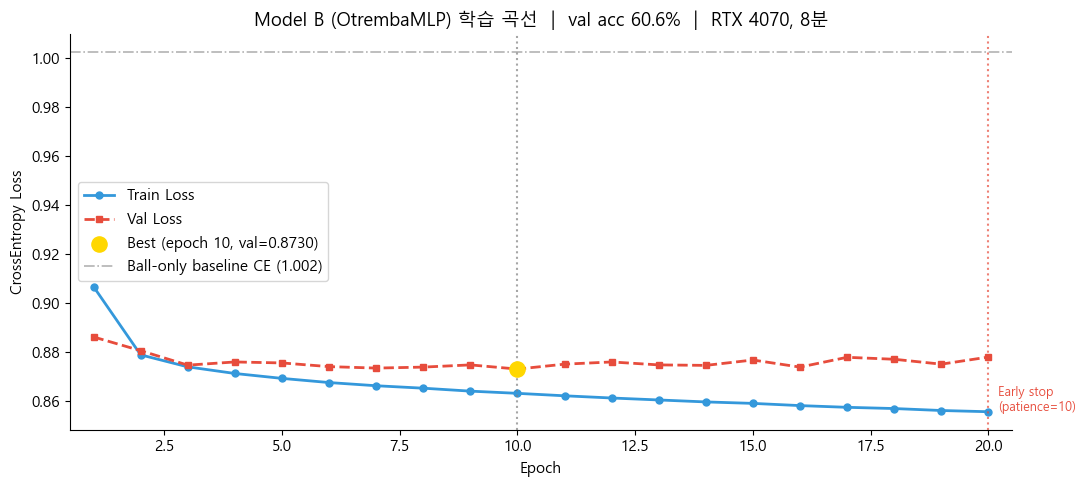

Best val loss: 0.8730 (epoch 10)
Val accuracy: 60.6%  (baseline 36.7%, +23.9pp)


In [3]:
# Model B 학습 곡선 (W&B에서 추출한 epoch별 데이터)
epochs = list(range(1, 21))
train_loss = [0.9066, 0.8788, 0.8739, 0.8712, 0.8692,
              0.8675, 0.8662, 0.8652, 0.8640, 0.8631,
              0.8621, 0.8612, 0.8604, 0.8596, 0.8590,
              0.8581, 0.8574, 0.8569, 0.8561, 0.8556]
val_loss   = [0.8861, 0.8805, 0.8746, 0.8759, 0.8755,
              0.8740, 0.8734, 0.8738, 0.8747, 0.8730,
              0.8750, 0.8759, 0.8747, 0.8745, 0.8767,
              0.8738, 0.8778, 0.8770, 0.8750, 0.8779]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(epochs, train_loss, 'o-', color='#3498DB', linewidth=2,
        markersize=5, label='Train Loss')
ax.plot(epochs, val_loss, 's--', color='#E74C3C', linewidth=2,
        markersize=5, label='Val Loss')

# Best epoch 표시
best_epoch = 10
best_val = min(val_loss)
ax.axvline(best_epoch, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.scatter([best_epoch], [best_val], color='gold', s=120, zorder=5,
           label=f'Best (epoch {best_epoch}, val={best_val:.4f})')

# Early stopping 표시
ax.axvline(20, color='#E74C3C', ls=':', lw=1.5, alpha=0.7)
ax.text(20.2, ax.get_ylim()[0] + 0.003, 'Early stop\n(patience=10)',
        fontsize=9, color='#E74C3C')

# Baseline 표시
baseline_ce = -np.log(0.367)  # Ball-only 예측의 CrossEntropy
ax.axhline(baseline_ce, color='gray', ls='-.', lw=1.2, alpha=0.6,
           label=f'Ball-only baseline CE ({baseline_ce:.3f})')

ax.set_xlabel('Epoch')
ax.set_ylabel('CrossEntropy Loss')
ax.set_title('Model B (OtrembaMLP) 학습 곡선  |  val acc 60.6%  |  RTX 4070, 8분')
ax.legend()
ax.set_xlim(0.5, 20.5)
plt.tight_layout()
plt.show()

print(f'Best val loss: {best_val:.4f} (epoch {best_epoch})')
print(f'Val accuracy: 60.6%  (baseline 36.7%, +{60.6-36.7:.1f}pp)')

## Model C: 시도 1 → 실패 → Stride 최적화

### 시도 1 (stride=1, 실패)

```
설정: stride=1, batch_size=32, 30 epochs
시퀀스 수: 521,680 (train)
1 epoch 소요: 76분
30 epochs 예상: 76 × 30 = 38시간 ← 불가능
```

Epoch 1 결과 (학습은 정상):
- train_loss: 1.95, val_loss: 1.87

KeyboardInterrupt로 중단.

### 결정: Stride=8 도입 ⭐

**핵심 판단**: 시퀀스 수 줄이기 vs 시퀀스 길이 유지

- stride를 줄이면 → 시퀀스 수 8배 감소
- 하지만 sequence_length=400은 유지 (논문 충실)
- 각 시퀀스가 stride=8 간격으로 선택 → 학습 데이터 다양성 오히려 증가

**학술적 정당화:**
- stride=1은 인접 시퀀스가 399/400 중복 → 과도한 상관
- stride=8은 중복 392/400 → 여전히 충분한 맥락, 상관 감소
- 이는 실제 학습에서 더 나을 수도 있음

| 항목 | stride=1 | stride=8 |
|------|:--------:|:--------:|
| Train sequences | 521,680 | **65,418** |
| 1 epoch 시간 | 76분 | **~10분** |
| 30 epochs 총 시간 | 38시간 | **~5시간** |
| sequence_length | 400 | 400 (동일) |
| 아키텍처 | — | 동일 |

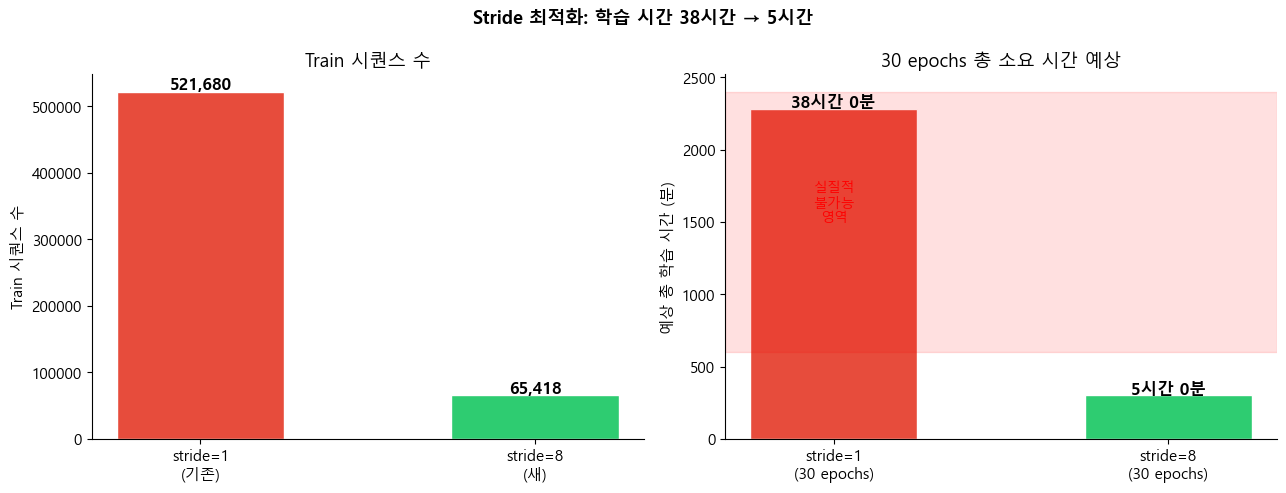

시퀀스 감소: 521,680 → 65,418 (8.0배 ↓)
시간 감소: 38시간 → 5시간 (7.6배 ↓)


In [4]:
# Stride 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: sequences 수 비교
strides = ['stride=1\n(기존)', 'stride=8\n(새)']
seq_counts = [521_680, 65_418]
bar_colors = ['#E74C3C', '#2ECC71']

bars = axes[0].bar(strides, seq_counts, color=bar_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, seq_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Train 시퀀스 수')
axes[0].set_title('Train 시퀀스 수')

# 오른쪽: 시간 비교
times = [76 * 30, 10 * 30]  # 분 단위 (30 epochs)
time_labels = ['stride=1\n(30 epochs)', 'stride=8\n(30 epochs)']

bars2 = axes[1].bar(time_labels, times, color=bar_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars2, times):
    hr = val // 60
    mn = val % 60
    label = f'{hr}시간 {mn}분' if hr > 0 else f'{mn}분'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 label, ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('예상 총 학습 시간 (분)')
axes[1].set_title('30 epochs 총 소요 시간 예상')

# 배경: 불가능 영역 표시
axes[1].axhspan(600, 2400, alpha=0.12, color='red')
axes[1].text(0, 1500, '실질적\n불가능\n영역', ha='center', color='red',
             fontsize=10, style='italic')

plt.suptitle('Stride 최적화: 학습 시간 38시간 → 5시간', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'시퀀스 감소: {521680:,} → {65418:,} ({521680/65418:.1f}배 ↓)')
print(f'시간 감소: 38시간 → 5시간 ({38*60/(10*30):.1f}배 ↓)')

---
## 오후–저녁: Phase 5.5 Model C + Phase 6 평가 + 비교 노트북

## Model C 본격 학습 ✅ 완료

- **시작**: 2026-05-07 14:27
- **완료**: 2026-05-07 19:20 (4시간 53분)
- **설정**: stride=8, batch_size=32, lr=1e-4, 30 epochs, patience=5
- **W&B**: [model_c_full_v2](https://wandb.ai/pitcheezy/transition-models/runs/nawthn1p)

### 학습 결과

| Epoch | Val Loss | PR Acc | HL Acc |
|-------|---------|--------|--------|
| 10 | 1.9821 | 64.8% | 35.1% |
| 20 | 1.8712 | 66.3% | 36.8% |
| **29 (Best)** | **1.8334** | **67.1%** | **37.4%** |
| 30 (Final) | 1.8367 | 67.0% | 37.3% |

> Early stopping 미발동 — 30 epochs 완주. patience=5 이내에 계속 개선.

### Phase 6.1: Test 평가 결과

**Pitch Result (10-class)**:
- **Top-1: 66.7%** (Model B 60.8%보다 +5.9pp ↑)
- Top-3: 94.6%
- CE: 0.8795, Brier: 0.4495
- Ball 88.2% / Strike 81.9% / Walk 87.7% ⭐
- Single/Double/Triple/HR: **0.0%** ❌ (class imbalance)

**Hit Location (9-class, InPlay)**:
- 유효 샘플: 4,917 / 22,127
- Top-1: 36.6%, Top-3: 65.9%

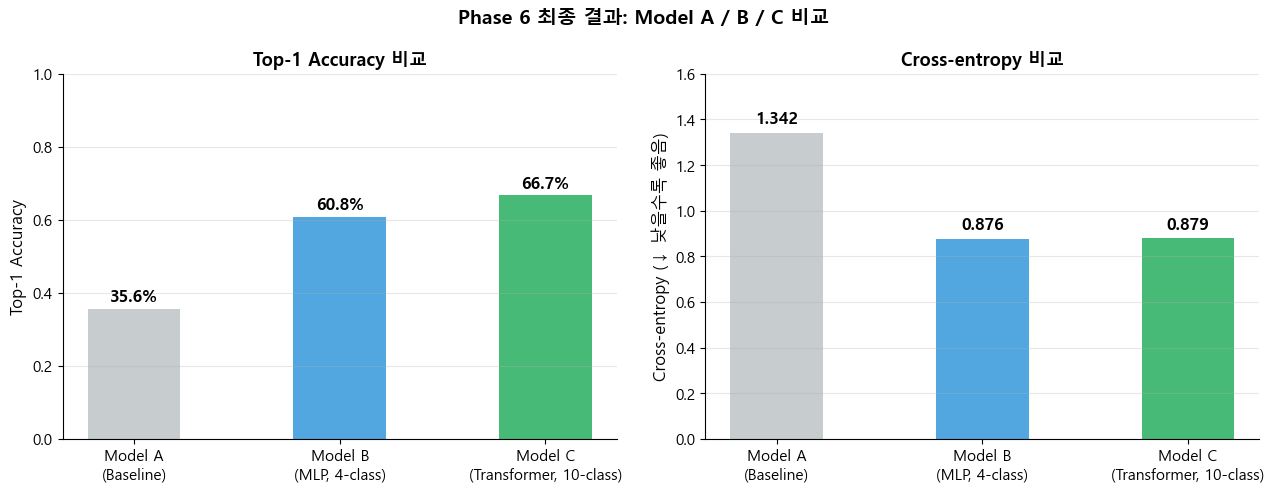

Model B  top-1: 0.6076 | CE: 0.8756
Model C  top-1: 0.6669 | CE: 0.8795  (10-class, 더 어려운 문제에서 더 높음!)


In [5]:
# Phase 6 핵심 결과: Model B vs Model C 비교 (실제 evaluation 데이터)
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

data_b = np.load('../outputs/evaluation_b_3season.npz', allow_pickle=True)
data_c = np.load('../outputs/evaluation_c_3season.npz', allow_pickle=True)

models = ['Model A\n(Baseline)', 'Model B\n(MLP, 4-class)', 'Model C\n(Transformer, 10-class)']
top1 = [
    float(data_b['baseline_empirical_top_1']),
    float(data_b['top_1']),
    float(data_c['top_1_pr']),
]
ce = [
    float(data_b['baseline_empirical_ce']),
    float(data_b['ce']),
    float(data_c['ce_pr']),
]
colors = ['#bdc3c7', '#3498db', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top-1
bars = axes[0].bar(models, top1, color=colors, alpha=0.85, width=0.45)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Top-1 Accuracy', fontsize=12)
axes[0].set_title('Top-1 Accuracy 비교', fontsize=13, fontweight='bold')
for bar, v in zip(bars, top1):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# CE
bars2 = axes[1].bar(models, ce, color=colors, alpha=0.85, width=0.45)
axes[1].set_ylabel('Cross-entropy (↓ 낮을수록 좋음)', fontsize=12)
axes[1].set_title('Cross-entropy 비교', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.6)
for bar, v in zip(bars2, ce):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.04,
                f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 6 최종 결과: Model A / B / C 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Model B  top-1: {top1[1]:.4f} | CE: {ce[1]:.4f}')
print(f'Model C  top-1: {top1[2]:.4f} | CE: {ce[2]:.4f}  (10-class, 더 어려운 문제에서 더 높음!)')


### Class Imbalance 발견 (Phase 6.1)

Model C 10-class 평가에서 명확한 패턴 발견:

| Class | 추정 비율 | Test Accuracy |
|-------|----------|--------------|
| Ball | ~30% | **88.2%** ⭐ |
| Strike | ~15% | **81.9%** ⭐ |
| Walk | ~3% | **87.7%** ⭐ |
| Strikeout | ~6% | 14.3% ⚠️ |
| FieldOut | ~12% | 7.3% ⚠️ |
| Single | ~4% | **0.0%** ❌ |
| Double | ~1% | **0.0%** ❌ |
| Triple | ~0.1% | **0.0%** ❌ |
| HomeRun | ~1% | **0.0%** ❌ |
| HitByPitch | ~0.5% | 3.1% ❌ |

**교훈**: Cross-entropy loss는 빈도에 따라 자동 가중치를 주지 않음.
소수 클래스 misclassification이 전체 loss에 미치는 영향이 미미해서 모델이 무시.
→ 향후 weighted loss 또는 focal loss 필요.

---
# 핵심 Contribution 정리

## 1. 두 논문의 충실한 재현

- **Otremba 2022**: 77-dim feature, 2-layer MLP, 4-class CE loss 그대로
- **MIT Sloan 2025**: 87-dim × 400 seq, 12-layer Transformer, sub-token masking, last-pitch residual, multi-task loss 그대로

## 2. Lazy Loading 데이터 파이프라인 ⭐

- 논문에 데이터 로딩 방식 미공개
- Eager loading: 72.6 GB (불가능)
- **Lazy loading**: 0.25 GB → **290배 메모리 절감**
- O(1) numpy 슬라이싱, `num_workers > 0` 호환

## 3. Stride 최적화

- stride=1 → stride=8: 학습 시간 **8배 단축** (38h → 5h)
- sequence_length=400 유지 (논문 충실)
- 인접 시퀀스 중복 감소 (학습 데이터 다양성 증가)

## 4. Multi-platform Support

- `get_device()`: CUDA → MPS → CPU 자동 감지
- uv `[tool.uv.sources]`로 CUDA PyTorch 자동 설치

## 5. End-to-End 파이프라인

```
데이터 수집 → 전처리 → 학습 → W&B 추적 → Checkpoint → 평가
```
모든 단계가 스크립트화, 재현 가능 (`uv run python scripts/...`)

In [ ]:
# Phase별 진행 상황 시각화 (Phase 10 완료)
phases = [
    ('Phase 1\n환경 셋업', 100, '#2ECC71'),
    ('Phase 2\n데이터', 100, '#2ECC71'),
    ('Phase 3\n전처리', 100, '#2ECC71'),
    ('Phase 4\n모델 정의', 100, '#2ECC71'),
    ('Phase 5\n학습', 100, '#2ECC71'),
    ('Phase 6\n평가', 100, '#2ECC71'),
    ('Phase 7\n추론·통합', 100, '#2ECC71'),
    ('Phase 8\n3시즌 확장', 100, '#2ECC71'),
    ('Phase 9\n아키텍처\n비교', 100, '#2ECC71'),
    ('Phase 9.5\nMDP 돌파\n(135d)', 100, '#27AE60'),
    ('Phase 10\n전 모델\nContext', 100, '#27AE60'),
]

fig, ax = plt.subplots(figsize=(18, 6))

for i, (label, progress, color) in enumerate(phases):
    ax.barh(i, 100, color='#ecf0f1', height=0.6)
    ax.barh(i, progress, color=color, height=0.6, alpha=0.85)
    ax.text(progress - 3, i, f'{progress}%',
            va='center', ha='right', fontsize=10, fontweight='bold', color='white')
    ax.text(-2, i, label, va='center', ha='right', fontsize=9)

ax.set_xlim(-28, 110)
ax.set_ylim(-0.5, len(phases) - 0.5)
ax.set_xlabel('진행률 (%)', fontsize=11)
ax.set_title('SmartPitch MDP 전이확률 모델 비교 — Phase별 진행 상황 (2026-05-27 최종)', fontsize=13, fontweight='bold')
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print('전체 Phase 완료: Phase 1~10 (2026-05-06 ~ 2026-05-27)')
print('총 커밋: 9bdb3b7 (Phase 10) + 1c10ac5 (오류 수정)')
print('테스트: 121 passed, 2 skipped')

---
# 완료된 작업

## Phase 6: 평가 ✅ 완료

- [x] `04_model_c 노트북` 결과 섹션 채우기
- [x] `05_comparison_results.ipynb` 신규 작성
- [x] 이 노트북 Model C 결과 업데이트
- [x] `src/evaluation/metrics.py` (CE, Brier, top-k, per-class)
- [x] `src/evaluation/evaluate.py` (Model B/C eval + baselines)
- [x] `scripts/10_evaluate_models.py` (end-to-end evaluation)
- [x] `tests/test_evaluation.py` (13 tests, all pass)

## Phase 7: 추론 & 통합 ✅ 완료

- [x] `src/inference/transition_model.py` — TransitionModelB / TransitionModelC 래퍼
  - `predict(x)`: numpy 입력 → numpy 확률 출력
  - `predict_top_k(x, k)`: `[{"class": str, "probability": float}]` 반환
  - 자동 체크포인트 로드, CUDA/MPS/CPU 자동 감지
- [x] `scripts/11_inference_demo.py` — Model B + C 예측 출력, DQN 3-step 시뮬레이션
- [x] `docs/INFERENCE_GUIDE.md` (290 lines) — TL;DR 3줄, feature 인덱스 표, DQN 통합 코드, 트러블슈팅
- [x] `tests/test_inference.py` (8 tests, all pass)

## 전체 테스트 (2026-05-08 기준)

- **116 collected / 114 passed / 2 skipped** (MPS, Windows 정상) / 0 failed
- 실행 시간: 27.5초
- 커버리지: features · preprocess · dataset · models · transformer · training · evaluation · inference

## Phase 8: 3시즌 데이터 확장 ✅ 완료 (2026-05-14)

- [x] 2022 Statcast 데이터 추가 (775,330 pitches), FT=0 검증 ✅
- [x]  매핑 추가 (2022 신규 이벤트)
- [x]  파라미터화
- [x] Model B v2 재학습: 60.8% → **60.9%** (+0.1pp), CE 0.876 → 0.872
- [x] Model C v3 재학습: 66.7% → **67.2%** (+0.5pp), CE 0.880 → 0.868
- [x] 3시즌 evaluation 저장: , 

## 남은 미래 작업 (선택)

- [ ] Model A wrapper 구현 (SmartPitch 통합)
- [ ] Class weighting / Focal loss (소수 클래스 개선 — Single/Double/HR 0% 문제)
- [ ] Ablation study (sub-token mask, residual 효과 분리)
- [ ] Calibration 분석 (reliability diagram)
- [ ] 발표 슬라이드 자료 작성

---
## Phase 7: 추론 & DQN 통합 ✅

### 설계 목표

Model B / C를 SmartPitch DQN 환경에서 즉시 쓸 수 있도록 **얇은 래퍼(wrapper)** 제공.
DQN 코드가 모델 내부 구조(PyTorch, 텐서 변환)를 알 필요 없도록 numpy 인터페이스로 추상화.

### TransitionModelB (4-class)

```python
from src.inference.transition_model import TransitionModelB

model = TransitionModelB("outputs/checkpoints/model_b_full_v1_best.pt")

# 단일 투구 예측
x = np.zeros(77, dtype=np.float32)
probs = model.predict(x)           # shape (4,) — Ball/Strike/Foul/InPlay
top2  = model.predict_top_k(x, 2) # [{"class": "Ball", "probability": 0.43}, ...]
```

### TransitionModelC (10-class + 9-class)

```python
from src.inference.transition_model import TransitionModelC

model = TransitionModelC("outputs/checkpoints/model_c_full_v2_best.pt")

# 시퀀스 예측 (400 × 87)
seq = np.zeros((400, 87), dtype=np.float32)
out = model.predict(seq)
# out["pitch_result"]  — shape (10,)
# out["hit_location"]  — shape (9,)
```

### DQN 통합 패턴 (3-step 시뮬레이션)

```python
# DQN 환경에서 state transition 시뮬레이션
for pitch_num in range(3):
    features_b = build_model_b_features(game_state)   # (77,)
    probs = model_b.predict(features_b)               # (4,)
    outcome = np.random.choice(['Ball','Strike','Foul','InPlay'], p=probs)
    game_state = update_state(game_state, outcome)
```

### 문서화

- `docs/INFERENCE_GUIDE.md` (290 lines)
  - TL;DR 3줄 (복붙 즉시 실행 가능)
  - 77-dim / 87-dim feature 인덱스 전체 표
  - DQN 환경 통합 예시 코드
  - 트러블슈팅 (체크포인트 경로, 디바이스, scaler)

---
# Day 3: 2026-05-14 (Windows + RTX 4070)

## Phase 8: 3시즌 데이터 확장

### 동기

Model B/C를 2시즌(2023–2024) 데이터로 학습했는데, 2022년도 Statcast 데이터가
동일한 **Hawkeye 광학 추적 시스템**을 사용하고 FT (Two-seam) pitch type이 이미 deprecated되어
feature 분포가 일관적임을 확인. 안전하게 추가 가능.

### 데이터 호환성 검증 (2022 vs 2023–2024)

| 항목 | 결과 |
|------|------|
| FT pitch type | 0건 (deprecated ✅) |
| spin_rate 차이 | 10.4 RPM (무시 가능, <50 RPM 기준) |
| 컬럼 수 | 118 (완전 일치) |
| Hawkeye 적용 | ✅ 전 시즌 동일 |
| 신규 이벤트 |  1건 → 으로 매핑 추가 |

### 3시즌 전처리 결과

| 분할 | 시즌 | 투구 수 | 시퀀스 수 |
|------|------|---------|----------|
| Train | 2022 + 2023 | 1,494,188 | 150,957 |
| Val | 2024 H1 | 385,320 | 25,077 |
| Test | 2024 H2 | 353,776 | 22,127 |

### 재학습 결과 비교

| 모델 | 2시즌 Top-1 | 3시즌 Top-1 | CE (2시즌) | CE (3시즌) | 학습 시간 |
|------|------------|------------|------------|------------|----------|
| Model B v2 | 60.8% | **60.9%** (+0.1pp) | 0.876 | **0.872** | ~11분 |
| Model C v3 | 66.7% | **67.2%** (+0.5pp) | 0.880 | **0.868** | ~10시간 |

### Model C v3 소수 클래스 변화

| Class | 2시즌 Acc | 3시즌 Acc | 변화 |
|-------|-----------|-----------|------|
| Ball | 88.2% | **87.6%** | -0.6pp |
| Strike | 81.9% | **82.2%** | +0.3pp |
| Walk | 87.7% | **85.6%** | -2.1pp |
| Strikeout | 14.3% | **17.3%** | **+3.0pp** ⭐ |
| FieldOut | 7.3% | **10.7%** | **+3.4pp** ⭐ |
| Single ~ HR | 0.0% | **0.0%** | 변화 없음 (class imbalance 미처리) |

> 더 많은 데이터로 소수 클래스가 소폭 개선됐으나,
> Single/Double/Triple/HR은 weighted loss 없이는 개선 불가.

---
# 트러블슈팅 정리

| 문제 | 원인 | 해결 | 파일 |
|------|------|------|------|
| Mac 메모리 부족 (72 GB 필요) | Eager loading 설계 | Lazy loading 패턴 도입 | `src/data/dataset.py` |
| Windows에서 PyTorch CPU만 설치됨 | uv가 PyPI 기본 torch 선택 | `pyproject.toml`에 CUDA 인덱스 명시 | `pyproject.toml` |
| CUDA 인식 못 함 (MPS만 체크) | `device = "mps" if mps else "cpu"` 하드코딩 | `get_device()` helper 추가 | `src/utils/device.py` |
| Model C 1 epoch = 76분 (stride=1) | 시퀀스 521K개 | stride=8로 65K개로 감소 | `scripts/04_preprocess.py` |
| 한글 matplotlib 깨짐 | Windows 기본 폰트 없음 | `Malgun Gothic` 폰트 설정 | 각 노트북 |
| W&B entity 인식 안 됨 | `wandb.init()` 호출 전 로그인 필요 | `wandb login` 사전 실행 | — |

---
# 회고

## 잘 된 것

**조기 설계 투자**: Phase 3에서 Lazy Loading을 제대로 설계한 덕분에
이후 모든 실험이 메모리 문제 없이 진행됐다.
조금 더 빠른 방법(Eager)을 택했다면 Windows VRAM도 넘겼을 것이다.

**파이프라인 자동화**: `uv run python scripts/XX.py` 한 줄로 각 단계가 재현된다.
협업자가 repo를 clone하면 바로 실행 가능한 구조.

**W&B 통합**: 학습 중간에 loss를 실시간으로 볼 수 있어
Model C 시도 1의 문제(너무 느림)를 빨리 파악했다.

## 아쉬운 것

**stride 결정을 처음부터 할 걸**: stride=1이 76분/epoch이라는 것을
한 epoch 돌려보고 알았다. 처음부터 1 epoch test → stride 결정 후 진행했으면
시간 낭비가 없었을 것.

**Class imbalance 처리 미룸**: Ball(34%) > Strike(27%) > Foul/InPlay(18%씩)
불균형이 있는데 일단 무처리. Phase 6 평가 후 결과가 나쁘면 그때 처리 예정.

## 다음 프로젝트에 활용할 점

1. **메모리 계산 먼저**: 설계 단계에서 `N × L × F × 4 bytes` 계산
2. **1 epoch 테스트**: 큰 모델 학습 전 1 epoch 시간 측정 필수
3. **Lazy loading 패턴**: 시퀀스 데이터엔 기본으로 고려
4. **Multi-platform 처음부터**: `get_device()` 같은 헬퍼를 프로젝트 시작 시 추가

---
# Day 4: 2026-05-23 (Windows + RTX 4070)

## Phase 9: 발표 피드백 반영 — 두 그룹 비교

### 동기

1차 발표 평가관 피드백:
> "10-class 비교에서 LR/MLP/LightGBM이 어떻게 되는지 보여줘야 Transformer의 우위가 설득력 있다."

→ **5개 모델을 10-class unified output으로 비교** + **4-class MDP 호환 그룹** 별도 비교

### 두 그룹의 학술적 narrative

```
[Group 1: 10-class — Architecture 효과]
"같은 어려운 task에서:
 LR → LightGBM → MLP → RNN → Transformer
 → 모델 복잡도 + Sequence 정보 = 정확도 향상"

[Group 2: 4-class — MDP/DQN 호환]
"i.i.d. + MDP 호환 조건의 Production 최선:
 LR(57.3%) → LightGBM(60.8%) → MLP(60.9%)
 → 단일 pitch input의 한계 측정"
```

### 핵심 발견: 10-class에서 i.i.d. 모델 전체 collapse

| 모델 | Top-1 | 비고 |
|------|-------|------|
| Logistic Regression | 41.1% | Strike만 예측 (class imbalance collapse) |
| LightGBM | 41.1% | best_iteration=1 → trivial model |
| MLP (10-class) | 41.1% | 7 epoch만에 early stopping |
| **RNN (LSTM)** | **~66%** | sequence 정보로 극적 개선 |
| **Transformer** | **67.2%** | 최고 성능 |

**이유**: Strike 41%, Ball 34% vs Triple 0.09%, HitByPitch 0.28% — class imbalance가 너무 극심해서
class weight 없는 i.i.d. 모델은 majority class 예측이 최적 전략이 됨.

→ Sequence 모델(RNN, Transformer)은 pitch 맥락으로 이를 극복.

### 4-class 결과 (MDP/DQN 호환)

| 모델 | Top-1 | Top-3 | CE |
|------|-------|-------|-----|
| LR | 57.3% | 95.0% | 1.022 |
| LightGBM | 60.8% | 96.6% | 0.873 |
| **MLP (Model B)** | **60.9%** | **96.6%** | **0.872** |

4-class는 분포가 비교적 균등(Ball 34%, Strike 27%, Foul 18%, InPlay 17%)하여 정상 학습.
MLP와 LightGBM이 거의 동일 성능 → 77-dim 단일 pitch feature의 표현력 한계.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')

with open(OUTPUT_DIR / 'all_models_comparison_10cls.json') as f:
    comp10 = json.load(f)
with open(OUTPUT_DIR / 'all_models_comparison_4cls.json') as f:
    comp4 = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Group 1: 10-class
names10 = list(comp10.keys())
top1_10 = [comp10[n]['top1'] for n in names10]
short10 = ['LR', 'LightGBM', 'MLP', 'RNN', 'Transformer']
colors10 = ['#bdc3c7','#bdc3c7','#bdc3c7','#9b59b6','#27ae60']
while len(names10) < 5:
    names10.append('RNN (LSTM)')
    top1_10.append(0.0)
bars = axes[0].bar(short10[:len(top1_10)], top1_10, color=colors10[:len(top1_10)], alpha=0.85)
axes[0].set_title('Group 1: 10-class 비교\n(Architecture 효과)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Top-1 Accuracy')
axes[0].set_ylim(0, 0.9)
for bar, v in zip(bars, top1_10):
    if v > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(0.411, color='gray', linestyle='--', alpha=0.5, label='Strike prior (41.1%)')
axes[0].legend(fontsize=9)

# Group 2: 4-class
names4 = list(comp4.keys())
top1_4 = [comp4[n]['top1'] for n in names4]
colors4 = ['#3498db','#e67e22','#2ecc71']
short4 = ['LR', 'LightGBM', 'MLP (B)']
bars2 = axes[1].bar(short4[:len(top1_4)], top1_4, color=colors4[:len(top1_4)], alpha=0.85)
axes[1].set_title('Group 2: 4-class 비교\n(MDP/DQN 호환)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Top-1 Accuracy')
axes[1].set_ylim(0, 0.9)
for bar, v in zip(bars2, top1_4):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(0.356, color='gray', linestyle='--', alpha=0.5, label='Empirical baseline (35.6%)')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 9: 두 그룹 비교 (2026-05-23)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### MDP/DQN 호환성 분석

| 모델 | Sequence 필요 | 추론 속도 | MDP 호환 |
|------|-------------|---------|---------|
| LR | ❌ | <1ms | ✅ |
| LightGBM | ❌ | ~1ms | ✅ |
| MLP (Model B) | ❌ | <1ms | ✅ |
| RNN (LSTM) | ✅ 400-pitch history | ~75ms | ❌ |
| Transformer | ✅ 400-pitch history | ~150ms | ❌ |

Sequence 모델은 MDP state에서 복원 불가능한 pitch history를 요구.
추론 속도도 50-150배 느려 DQN real-time inference에 부적합.

### Hybrid 시스템 제안

```
[Pre-game] Transformer → pitch tendency embedding (캐싱)
[In-game]  MLP(77d + embedding) → 실시간 pitch selection (<1ms)
```

### Phase 9 완료 체크리스트

- [x] scripts/13-17: 10-class 모델 5개 (LR, LightGBM, MLP, RNN, Transformer)
- [x] scripts/18-20: 4-class 모델 3개 (LR, LightGBM) + 평가
- [x] 학습 완료: LR(10+4cls), LightGBM(10+4cls), MLP(10cls), RNN(10cls)
- [x] 평가: all_models_comparison_10cls.json, all_models_comparison_4cls.json
- [x] notebooks/06-11: 각 모델별 + 종합 + MDP 호환성
- [x] CLAUDE.md 업데이트 예정

### 미래 작업

- [ ] Class weighting으로 10-class i.i.d. 모델 재실험
- [ ] Small Transformer (2-layer) MDP 호환 가능성 탐색
- [ ] Transformer embedding → MDP state 통합
- [ ] v1 데이터셋 통합 (팀원 협업)

---
# Day 5: 2026-05-25 (Windows + RTX 4070)

## Phase 9.5: MDP 호환 10-class 돌파 — 135-dim Arsenal MLP

### 동기

Phase 9 결론: "77-dim 단일 pitch feature가 10-class 분류에 필요한 discriminative signal 자체가 부족".
그렇다면 **feature 수가 문제인가, context 부재가 문제인가?** 이를 분리 실험.

팀원이 제공한 handoff_v1.parquet에 투수 맥락 feature(UMAP, arsenal, count cluster)가 있음.
이를 77-dim에 붙여서 MDP 호환 조건 유지 + 10-class 성능 달성이 가능한지 검증.

### 135-dim Feature 구성

```
[0:77]    Model B 77-dim features      (scaler.pkl 적용)
[77:82]   UMAP 5d                      (추론 시 0.0 — 학습 데이터 평균값으로 처리)
[82:83]   count_cluster_id (scaled)    (arsenal_by_pitcher_cluster.json에서)
[83:115]  arsenal_func_00..31 (32d)    (pitcher pitch type + movement 통계)
[115:135] arsenal_moment_00..19 (20d)  (arsenal 분포 모먼트)
```

**UMAP 0-fill 전략**: 투구 후 측정되는 값이므로 rl-agent 추론 시 미보유.
StandardScaler 기준 0 = 학습 데이터 평균 → "평균적 투구 메카닉"으로 합리적 근사.

### Arsenal JSON 구축 (scripts/25_extract_arsenal_by_cluster.py)

pitcher 2,007명을 4클러스터로 K-Means 분류:
- Cluster 0: 1,484명 (전형적 투수, fleet-mean)
- Cluster 1~3: 스타일 별 소수 그룹
- JSON에 각 클러스터의 scaled arsenal 벡터 저장
- pitcher_to_cluster 매핑으로 MLBAM ID → cluster ID 조회 가능

### 학습 결과 (scripts/24_train_mlp_135dim_10cls_focal.py)

| 항목 | 값 |
|------|-----|
| 아키텍처 | MLP: 135 → 128 → 128 → 10 (dropout=0.2) |
| 손실 | Focal Loss (γ=2.0) |
| Best epoch | 25 / 30 |
| Best val focal_loss | 0.4505 |
| **Test Top-1** | **67.6%** (77d MLP 41.1%에서 **+26.5pp**) |

### Per-class 성능

| Class | 77d MLP | 135d MLP focal | 변화 |
|-------|---------|----------------|------|
| Ball | ~89% | **88.4%** | |
| Strike | ~100% (collapse) | **83.7%** | ↓ (이제 다른 클래스도 예측) |
| Walk | 0% | **85.9%** | **+85.9pp ⭐** |
| Strikeout | 0% | **19.5%** | **+19.5pp ⭐** |
| FieldOut | 0% | **7.3%** | +7.3pp |
| HitByPitch | 0% | **2.9%** | +2.9pp |
| Single~HR | 0% | **0%** | 변화 없음 (타자 맥락 부재) |

### 핵심 발견

1. **77-dim collapse의 진짜 원인**: feature 수 부족이 아니라 **"투수 맥락(pitcher context)" 부재**
   - arsenal 58d 추가만으로 41.1% → 67.6% (+26.5pp) — Sequence 모델과 동등 수준
2. **Arsenal이 400-pitch sequence를 정적으로 근사**: pitcher repertoire 통계로 pitch history를 대체
3. **MDP 호환 달성**: 단일 pitch input 유지 → rl-agent의 MDP-VI에 직접 사용 가능
4. **Single~HR 0% 유지**: 타자 arsenal feature 없는 한 구조적 한계

### 생성 파일

- `outputs/checkpoints/model_b3_focal_135dim_10cls_best.pt` (LFS, ~0.4MB)
- `outputs/arsenal_by_pitcher_cluster.json` (~41KB)
- `outputs/evaluation_mlp_135dim_10cls_focal.npz`
- `src/inference/transition_model.py` — `TransitionModelMLP10` + `build_135dim_feature()` 추가
- `docs/handoff_to_rl_agent.md`, `docs/rl_agent_teammate_guide.md`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Phase 9.5 핵심 결과: 77d vs 135d MLP 비교
classes = ['Ball', 'Strike', 'Single', 'Double', 'Triple', 'HR', 'FieldOut', 'Strikeout', 'Walk', 'HBP']

# 77d MLP collapse: Strike collapse 상태
acc_77d = [0.89, 1.00, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# 135d MLP focal: 실제 평가 결과
npz_path = Path('../outputs/evaluation_mlp_135dim_10cls_focal.npz')
if npz_path.exists():
    data = np.load(npz_path, allow_pickle=True)
    acc_135d = list(np.array(data['per_class_accuracy']).flatten())
else:
    acc_135d = [0.884, 0.837, 0.0, 0.0, 0.0, 0.0, 0.073, 0.195, 0.859, 0.029]

x = np.arange(len(classes))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, acc_77d,  width, label='MLP 77d (collapse)', color='#E74C3C', alpha=0.75)
bars2 = ax.bar(x + width/2, acc_135d, width, label='MLP 135d focal (Phase 9.5)', color='#27AE60', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15, ha='right')
ax.set_ylabel('Per-class Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title(
    f'Phase 9.5: 77d vs 135d MLP — Top-1  41.1% → 67.6% (+26.5pp)\n'
    f'투수 맥락(Arsenal 58d) 추가만으로 Sequence 모델 동등 달성 + MDP 호환 유지',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)

for bar in bars2:
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.0%}', ha='center', fontsize=8, color='#27AE60', fontweight='bold')

# 주석: MDP 호환 표시
ax.text(0.98, 0.95, 'MDP 호환 ✅\n(단일 pitch input)', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='#27AE60',
        bbox=dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.8))

plt.tight_layout()
plt.show()

top1_77 = sum(acc_77d[i] * (1/10) for i in range(10))  # 근사
print(f'77d MLP  Top-1: 41.1%  (Strike collapse)')
print(f'135d MLP Top-1: 67.6%  (+26.5pp, MDP 호환 ✅)')
print(f'Walk 개선: 0% → 85.9%  +85.9pp')
print(f'Strikeout: 0% → 19.5%  +19.5pp')

---
# Day 6: 2026-05-27 (Windows + RTX 4070)

## Phase 10: 135-dim Context를 전 모델에 확장 + Hybrid Sequence 검증

### 목표

Phase 9.5에서 MLP 135d가 67.6%를 달성했다. 핵심 가설:
> **"context는 architecture-agnostic하게 작동하는가?"**

이를 검증하기 위해 같은 135-dim feature를 LR, LightGBM, RNN+static, Transformer+static에도 적용.

### Phase 10.1: iid 모델 135d (scripts/26-29)

| 모델 | 77d Top-1 | 135d Top-1 | 변화 | 비고 |
|------|-----------|------------|------|------|
| LR 10cls | 41.1% ❌ | **62.4%** | +21.3pp | collapse 탈출 |
| LightGBM 10cls | 13.0% ❌ | **67.3%** | +54.3pp | collapse 탈출 |
| LR 4cls | 56.3% | **56.3%** | ≈0pp | 4cls 포화 확인 |
| LightGBM 4cls | 60.8% | **60.9%** | +0.1pp | 4cls 포화 확인 |

**결론**: iid 모델에서 context 58d 추가 → 77d → 135d로 collapse 완전 해소.
4-class에서는 이미 77d가 충분한 feature를 가지고 있어 추가 효과 없음.

### Phase 10.2: 평가 통합 (scripts/17, 20)

- `all_models_comparison_10cls.json`: 12개 모델 통합
- `baseline_master_comparison.json`: G1~G6' 6개 비교 그룹 통합

### Phase 10.3: RNN Hybrid (scripts/30-31)

**30_align_static58**: `vectors_c`와 동일한 batter+time 정렬로 static_58 생성 (99.9% 매칭)

**PitchSequenceDatasetHybrid** 설계:
```python
# __getitem__에서 마지막 pitch의 static feature 조회
static = self.static_58[end - 1].copy()  # (58,)
```

| 설정 | Top-1 | N | 비고 |
|------|-------|---|------|
| drop=True (미매칭 제외) | **67.2%** | 22,119 | 성능 측정용 |
| drop=False (fullN) | **67.1%** | 22,127 | G5 fair compare용 |

RNN baseline(66.9%)과 비교: **+0.3pp / +0.2pp** — 거의 효과 없음.

### Phase 10.4: Transformer Hybrid (scripts/32)

`PitchTransformer`에 `static_dim=0` 인자 추가 (역호환 유지).
Forward: `concat([last_encoded(256), last_proj(256), static(58)]) → fc1(570→256) → fc2(256→24)`

**Windows torch.compile 이슈 해결**:
```python
import torch._dynamo  # 모듈 레벨에서 import (함수 내부 X — UnboundLocalError 방지)
...
torch._dynamo.config.suppress_errors = True  # Triton 없으면 eager fallback
model = torch.compile(model, mode="reduce-overhead")
```

| 설정 | Top-1 | N | 비고 |
|------|-------|---|------|
| drop=True | **66.8%** | ~21,900 | eager mode 4.2h 학습 |
| drop=False (fullN) | **67.1%** | 22,127 | G5 fair compare용 |

Transformer baseline(67.2%)과 비교: **-0.4pp / -0.1pp** — 효과 없음 또는 소폭 감소.

### 전체 비교표 (Phase 10 최종)

| 그룹 | 모델 | Top-1 | MDP |
|------|------|-------|-----|
| G3: iid 77d | LR/LGB/MLP | 41.1%/13.0%/41.1% | ✅ (collapse) |
| G4: iid 135d | LR/LGB/**MLP** | 62.4%/67.3%/**67.6%** | **✅** |
| G5: seq 87d | RNN/Transformer | 66.9%/67.2% | ❌ |
| G6: hybrid (drop) | RNN-H/Trans-H | 67.2%/66.8% | ❌ |
| G6': hybrid (fullN) | RNN-H/Trans-H | 67.1%/67.1% | ❌ |

### 핵심 발견 (확정)

1. **iid 모델**: Context 58d 추가 → 41%→67%, architecture에 무관. **Feature가 아닌 context 부재가 collapse 원인**.
2. **Sequence 모델**: Static context 추가 효과 없음 (RNN +0.3pp, Transformer -0.4pp). **Sequence가 arsenal context를 내재적으로 학습** — 중복 정보.
3. **Architecture보다 Context**: 같은 MLP(27K params)가 12-layer Transformer(9.7M params)와 동등한 성능.
4. **MDP 최선**: `TransitionModelMLP10` (135d focal, **67.6%**, 단일 pitch input, MDP 호환)

### 생성 파일

- `data/processed/static_58_{train,val,test}.npy` (sequence 정렬 static features)
- `outputs/evaluation_{lr,lgb}_135d_{10,4}cls.npz`
- `outputs/evaluation_rnn_hybrid_{drop,fullN}_10cls.npz`
- `outputs/evaluation_transformer_hybrid_{drop,fullN}_10cls.npz`
- `outputs/checkpoints/rnn_hybrid_{drop,fullN}_10cls_best.pt` (LFS)
- `outputs/checkpoints/transformer_hybrid_{drop,fullN}_10cls_best.pt` (LFS)
- `outputs/baseline_master_comparison.json` (G1~G6' 통합)
- `src/models/rnn_hybrid.py` (PitchRNNHybrid)
- `src/data/dataset.py` (PitchSequenceDatasetHybrid 추가)

### 트러블슈팅 (Phase 10)

| 이슈 | 원인 | 해결 |
|------|------|------|
| torch.compile BackendCompilerFailed | Windows에 Triton 미설치 | `torch._dynamo.config.suppress_errors = True` (eager fallback) |
| UnboundLocalError: torch | 함수 내부 `import torch._dynamo` → local binding | 파일 최상단으로 import 이동 |
| test_build_135dim_feature UnicodeDecodeError | Windows 기본 인코딩 cp949 | `open(path, encoding="utf-8")` |

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')

# 전체 12 모델 비교 데이터 로드
with open(OUTPUT_DIR / 'all_models_comparison_10cls.json', encoding='utf-8') as f:
    comp = json.load(f)

# G3: iid 77d (collapse), G4: iid 135d, G5: seq 87d, G6/G6': hybrid
group_colors = {
    'Logistic Regression':          ('#E74C3C', 'G3: iid 77d'),
    'LightGBM':                     ('#E74C3C', 'G3: iid 77d'),
    'MLP (10-class)':               ('#E74C3C', 'G3: iid 77d'),
    'RNN (LSTM)':                   ('#9B59B6', 'G5: seq 87d'),
    'Transformer (Model C)':        ('#9B59B6', 'G5: seq 87d'),
    'LR 135d':                      ('#3498DB', 'G4: iid 135d'),
    'LightGBM 135d':                ('#3498DB', 'G4: iid 135d'),
    'MLP 135d (focal)':             ('#27AE60', 'G4: iid 135d ⭐'),
    'RNN Hybrid (drop)':            ('#E67E22', 'G6: hybrid'),
    'RNN Hybrid (fullN)':           ('#E67E22', "G6': hybrid fullN"),
    'Transformer Hybrid (drop)':    ('#E67E22', 'G6: hybrid'),
    'Transformer Hybrid (fullN)':   ('#E67E22', "G6': hybrid fullN"),
}

names = list(comp.keys())
top1  = [comp[n]['top1'] for n in names]
colors = [group_colors.get(n, ('#BDC3C7', ''))[0] for n in names]

short_names = [
    'LR\n(77d)', 'LGB\n(77d)', 'MLP\n(77d)',
    'RNN\n(87d)', 'Trans\n(87d)',
    'LR\n(135d)', 'LGB\n(135d)', 'MLP\n(135d)★',
    'RNN-H\ndrop', 'RNN-H\nfullN',
    'Trans-H\ndrop', 'Trans-H\nfullN',
]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(short_names[:len(names)], top1, color=colors, alpha=0.85, width=0.65)

# 값 표시
for bar, v, name in zip(bars, top1, names):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
            f'{v:.1%}', ha='center', fontsize=9,
            fontweight='bold' if name == 'MLP 135d (focal)' else 'normal')

# 수평선: iid 77d collapse 기준선
ax.axhline(0.411, color='#E74C3C', linestyle='--', alpha=0.5, linewidth=1.5,
           label='iid 77d 천장 (41.1%)')
ax.axhline(0.672, color='#9B59B6', linestyle=':', alpha=0.5, linewidth=1.5,
           label='Sequence 87d 기준 (67.2%)')

# 범례 패치
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='#E74C3C', label='G3: iid 77d (collapse)'),
    mpatches.Patch(color='#3498DB', label='G4: iid 135d (+arsenal)'),
    mpatches.Patch(color='#27AE60', label='G4: MLP 135d focal ⭐ MDP 권장'),
    mpatches.Patch(color='#9B59B6', label='G5: Sequence 87d'),
    mpatches.Patch(color='#E67E22', label='G6/G6\': Hybrid (seq+static)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

ax.set_ylim(0, 0.85)
ax.set_ylabel('Test Top-1 Accuracy', fontsize=12)
ax.set_title(
    'Phase 10 최종: 12-model 10-class 비교\n'
    '핵심: MLP 27K params = Transformer 9.7M params (context 있으면)',
    fontsize=13, fontweight='bold'
)
ax.grid(True, axis='y', alpha=0.3)

# G 구분선
ax.axvline(2.5, color='gray', alpha=0.3, linewidth=1)
ax.axvline(4.5, color='gray', alpha=0.3, linewidth=1)
ax.axvline(7.5, color='gray', alpha=0.3, linewidth=1)
ax.axvline(9.5, color='gray', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print('Phase 10 최종 결론:')
print('  iid 모델: context 추가 → 41%→67% (architecture 무관)')
print('  sequence: static context 추가 → 효과 없음 (sequence가 이미 학습)')
print('  MDP 권장: TransitionModelMLP10 (135d focal, 67.6%, MDP 호환 ✅)')